# Kappa - Daughter-specific chromatin changes tuning


In [4]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from src.utils import mkdir_safe
from src.chromatin_deconvolution_solver import plot_example_fits
from src.chromatin_deconvolution_solver import plot_branches
from src.chromatin_model import plot_prediction
from src.geneset import get_deconvolved_geneset
from src.sgd import get_orfname
from src.RealDataReplication import read_n_fr_b
from src.chromatin_deconvolution_solver import subset_select_highest_G_indices


In [688]:
from src.chromatin_model import ChromatinModel
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs('distinct')
chromatin_model1 = ChromatinModel(config1)


todo: Loading testing config from replication deconvolution


In [870]:
from src.sgd import get_orfname
from src.sgd import read_nondubious_genes_dataset

genes = read_nondubious_genes_dataset()
orfname = get_orfname('SSK22')

gene = genes.loc[orfname]
tss = gene.TSS
chrom = gene.chr
mnase_span = tss-200, tss+200

chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_span(chrom=chrom, mnase_span=mnase_span)

Loading chromosome reads: 3
Applying a normalization for length distribution


In [871]:
from src.chromatin_gamma_search import ChromatinFindOptimalGamma
from src.chromatin_deconvolution_solver import ChromatinDeconvolveSolver

In [872]:
from src.chromatin_deconvolution_solver import dummy_N_frep_b, \
    subset_select_highest_G_indices

N, frep, b = dummy_N_frep_b(config1)
G_values, highest_Gs = subset_select_highest_G_indices(chromatin_model.G)
chromatin_solver = ChromatinDeconvolveSolver(config1, G_values, N, b, frep)

Completed. - 00:00:54.851


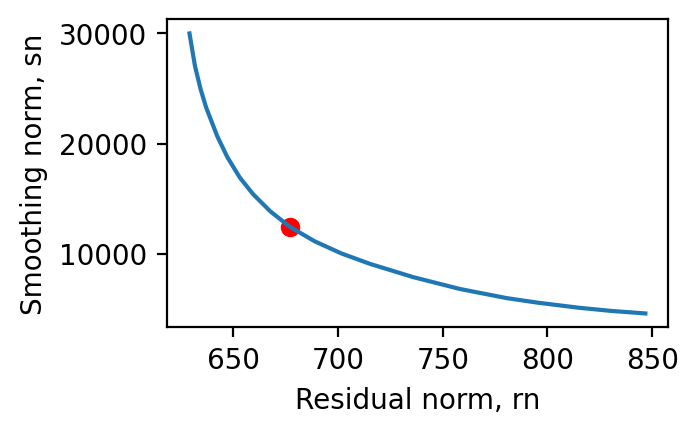

In [887]:
chrom_find_gamma = ChromatinFindOptimalGamma(chromatin_solver, gamma_min=0.001,
                                            gamma_max=1, verbose=False,
                                            kappa=0.01)
chrom_find_gamma.find_optimal_gamma()

In [888]:
optimal_gamma = chrom_find_gamma.gamma_optimizer.optimal_gamma
print("Initial gamma to begin kappa sweep: ", optimal_gamma)

Initial gamma to begin kappa sweep:  0.00763959944903568


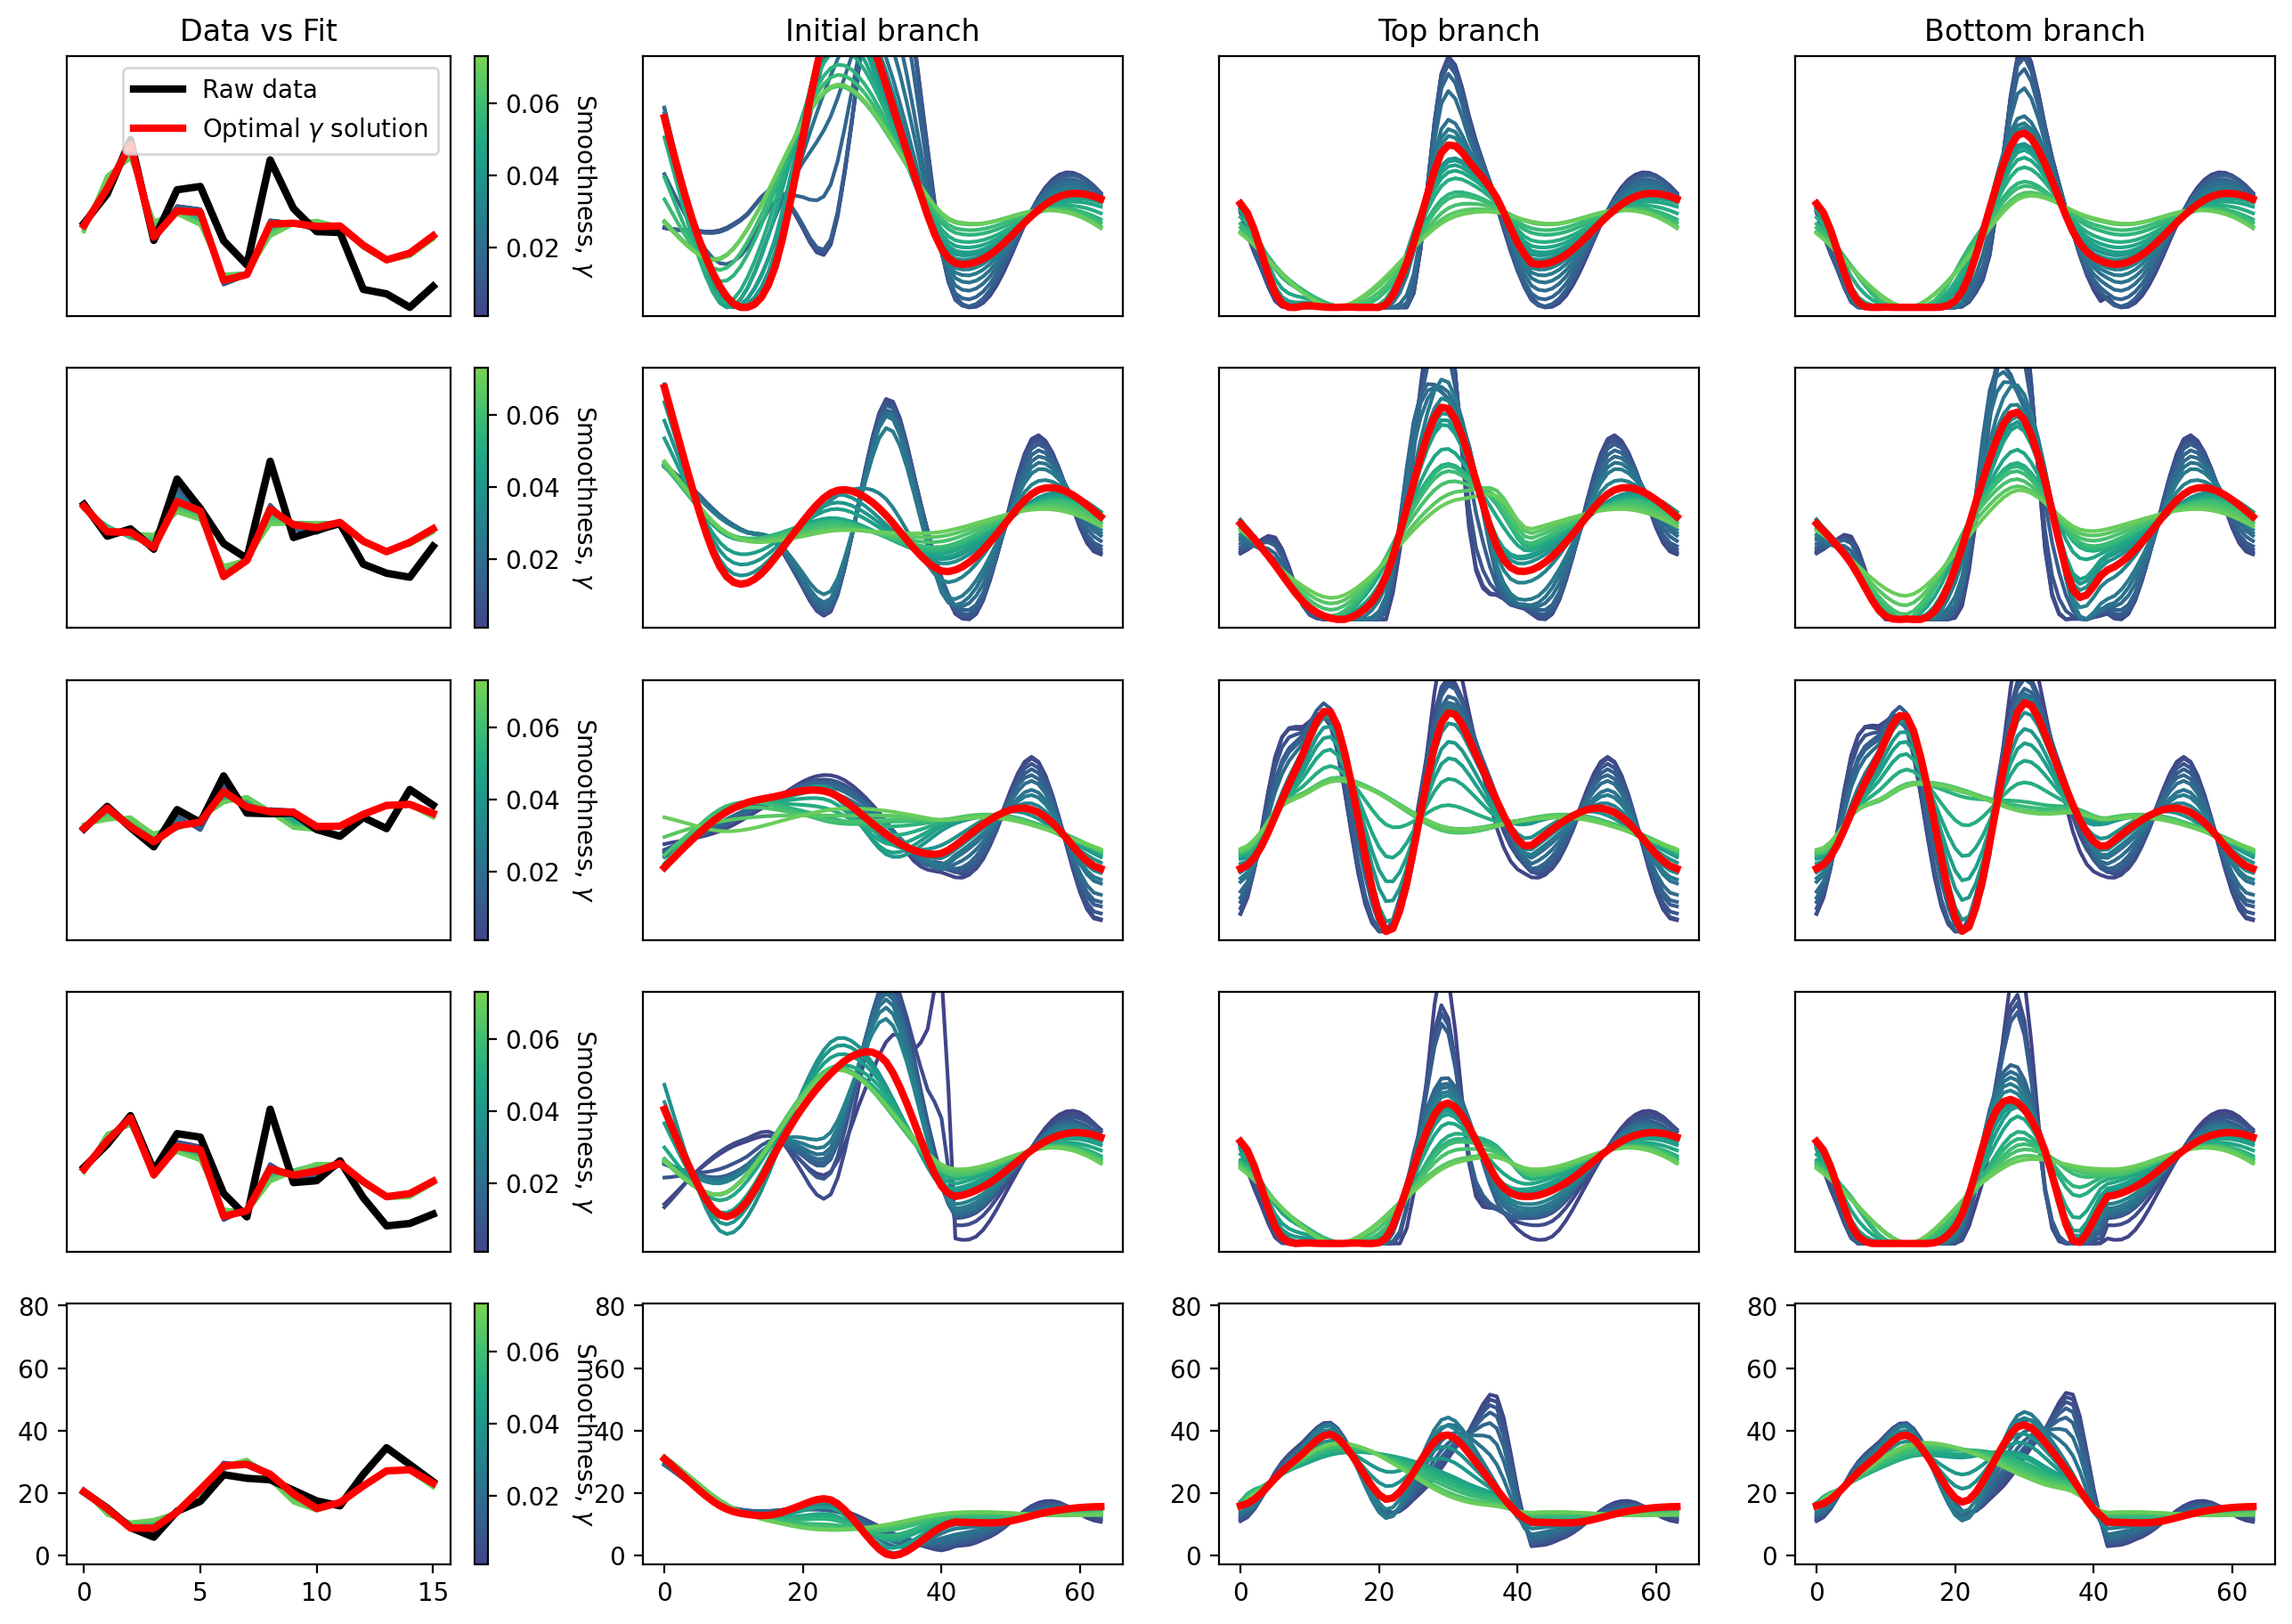

In [889]:
_ = chrom_find_gamma.plot_gamma_sweep()

Next, we are interested in DSE1 and SSK22as our initial signal to noise genes. 

Let's look at the chromatin for each of these, we are looking in the raw data for where
the signal should be for DSE1.

In [903]:
genes = get_deconvolved_geneset()

genes[genes['gene'] == 'RPL2A']

,gene,chr,cat,start,stop,strand,classification,length,TSS,PAS,manually_curated,promoter_start,promoter_end,gene_body_start,gene_body_end
orf_name,,,,,,,,,,,,,,,
YFR031C-A,RPL2A,6,gene,220507,221418,-,Verified,911,221479,220349,False,221479.0,221779.0,220979.0,221479.0


In [904]:
from src.timer import Timer

gene_names = ['SSK22', 'DSE1', 'DSE2', 'CLB2', 'MCM6',
              'RPL1A', 'RPL2A', 'DSE3', 'DSE4', 'CLN2']
timer = Timer()

gamma = 0.0076
kappa = 0.001

for gene_name in gene_names:
    print(gene_name)
    
    try:
        chromatin_solver = deconvolve_and_plot(gene_name, gamma, kappa,
            output_directory, padding=1200)
    except Exception as e:
        print(f"Skipping gene: ", gene_name, ", exception ", type(e))
    timer.print_time()


RPL1A
Skipping gene:  RPL1A , exception  'YPL220W'
00:00:00.066
RPL2A
Loading trial replication profile, 2/17/25
Loading chromosome reads: 6
Applying a normalization for length distribution
0/3120 - 00:00:00.000
500/3120 - 00:00:05.731
1000/3120 - 00:01:36.787
1500/3120 - 00:03:07.959
2000/3120 - 00:04:28.016
2500/3120 - 00:06:26.937
3000/3120 - 00:07:35.975
00:07:52.288
DSE3
Loading trial replication profile, 2/17/25
Loading chromosome reads: 15
Applying a normalization for length distribution
0/3120 - 00:00:00.001
500/3120 - 00:00:02.749
1000/3120 - 00:00:52.801
1500/3120 - 00:03:11.340
2000/3120 - 00:05:13.736
2500/3120 - 00:07:21.393
3000/3120 - 00:09:00.376
00:17:32.994
DSE4
Loading trial replication profile, 2/17/25
Loading chromosome reads: 14
Applying a normalization for length distribution
0/3120 - 00:00:00.001
500/3120 - 00:00:05.090
1000/3120 - 00:01:27.622
1500/3120 - 00:03:07.794
2000/3120 - 00:04:41.327
2500/3120 - 00:06:19.961
3000/3120 - 00:08:11.652
00:26:09.426
CLN2
L

In [908]:
# Retrieve chip data at mcm6

genes = get_deconvolved_geneset()

orfname = get_orfname("MCM6")

gene = genes.loc[orfname]
tss = gene.TSS
chrom = gene.chr
padding_2 = padding//2
mnase_span = tss-padding_2, tss+padding_2

mnase_span


(120910, 121010)

In [926]:
from src.sgd import get_chromosome_length
from src.geneset import get_deconvolved_geneset
genes_set = get_deconvolved_geneset()
genes_set

,gene,chr,cat,start,stop,strand,classification,length,TSS,PAS,manually_curated,promoter_start,promoter_end,gene_body_start,gene_body_end
orf_name,,,,,,,,,,,,,,,
YAL067W-A,YAL067W-A,1,gene,2480,2707,+,Uncharacterized,227,2480,2707,NaN,2180.0,2480.0,2480.0,2980.0
YAL067C,SEO1,1,gene,7235,9016,-,Verified,1781,9016,7235,NaN,9016.0,9316.0,8516.0,9016.0
YAL064C-A,YAL064C-A,1,gene,13363,13743,-,Uncharacterized,380,13743,13363,NaN,13743.0,14043.0,13243.0,13743.0
YAL064W,YAL064W,1,gene,21566,21850,+,Verified,284,21566,21850,NaN,21266.0,21566.0,21566.0,22066.0
YAL063C-A,YAL063C-A,1,gene,22395,22685,-,Uncharacterized,290,22685,22395,NaN,22685.0,22985.0,22185.0,22685.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YPR198W,SGE1,16,gene,934034,935665,+,Verified,1631,933984,935759,False,933684.0,933984.0,933984.0,934484.0
YPR199C,ARR1,16,gene,938148,939032,-,Verified,884,939059,937970,False,939059.0,939359.0,938559.0,939059.0
YPR200C,ARR2,16,gene,939279,939671,-,Verified,392,939779,939195,False,939779.0,940079.0,939279.0,939779.0


In [949]:
output_directory = 'output/daughter_specific_chromatin_intergenic'
mkdir_safe(output_directory)


Creating directory: output/daughter_specific_chromatin_intergenic...Directory exists. Skipping.


In [950]:
from src.sgd import get_intergenic_regions

# 500 bp away from genes, 10000 away from chromosome ends, and a minimum
# length of 500 base pairs

intergenic_regions_df = get_intergenic_regions(genes_set, buffer_genes=500, 
    buffer_chrom_end=10000, min_threshold_len=500)
intergenic_regions_df = intergenic_regions_df.reset_index(drop=True)


In [1392]:
# Compute set of canonical intergenic regions for testing
# Compute the coverage for each of these regions so we can filter
# out low coverage regions for testing.

timer = Timer()

print(f"Computing coverages for {len(intergenic_regions_df)} intergenic regions")
for i, intergenic_row in intergenic_regions_df.iterrows():

    # Skip if already computed
    if not np.isnan(intergenic_row.coverage): continue
        
    # Compute the coverage for these intergenic regions
    chrom = int(intergenic_row.chromosome)
    mnase_span = int(intergenic_row['start']), int(intergenic_row['end'])

    chromatin_model = ChromatinModel(config1)
    chromatin_model.load_mnase_span(chrom=chrom, mnase_span=mnase_span,
                                   log=False)

    array = chromatin_model.exact_bins

    coverage = (array > 0).any(axis=(0,1)).sum() / array.shape[2]

    intergenic_regions_df.loc[i, 'coverage'] = coverage
    
    if i % 50 == 0:
        timer.print_time(f"{i}/{len(intergenic_regions_df)}")


Computing coverages for 300 intergenic regions


/Users/trung/Research/deconvolution-python/src/chromatin_model.py:302: RuntimeWarning: Mean of empty slice.
  # Bins are filled up until the last one row and column, so subset
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/trung/Research/deconvolution-python/src/chromatin_model.py:302: RuntimeWarning: Mean of empty slice.
  # Bins are filled up until the last one row and column, so subset
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/trung/Research/deconvolution-python/src/chromatin_model.py:302: RuntimeWarning: Mean of empty slice.
  # Bins are filled up until the last one row and column, so subset
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvoluti

250/300 - 00:16:28.229


/Users/trung/Research/deconvolution-python/src/chromatin_model.py:302: RuntimeWarning: Mean of empty slice.
  # Bins are filled up until the last one row and column, so subset
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/trung/Research/deconvolution-python/src/chromatin_model.py:302: RuntimeWarning: Mean of empty slice.
  # Bins are filled up until the last one row and column, so subset
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/trung/Research/deconvolution-python/src/chromatin_model.py:302: RuntimeWarning: Mean of empty slice.
  # Bins are filled up until the last one row and column, so subset
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvoluti

In [1380]:
high_coverage_regions = intergenic_regions_df[intergenic_regions_df.coverage > 0.9] 
len(high_coverage_regions)

153

In [1394]:
intergenic_regions_df.to_csv('datasets/computed_mnase/intergenic_regions_gene500_chrom1000_min500.csv',
    index=False)

In [1393]:
intergenic_regions_df#.reset_index(drop=True)

,chromosome,start,end,length,coverage
0,1,3207,6735,3528,0.999433
1,1,9516,12863,3347,0.893305
2,1,14243,21066,6823,0.965406
3,1,28712,30689,1977,0.999494
4,1,70082,71260,1178,0.999150
...,...,...,...,...,...
295,16,880706,882702,1996,0.999499
296,16,927437,930848,3411,0.999707
297,16,936259,937470,1211,0.999174
298,16,941636,942268,632,0.998415


In [983]:
np.random.seed(123)

random_intergenic_indices = np.random.choice(high_coverage_regions.index.values, 
    size=5)
gamma = 0.0076
kappa = 0.001
timer = Timer()
for idx, intergenic_row in high_coverage_regions.loc[random_intergenic_indices].iterrows():
    
    chrom = int(intergenic_row['chromosome'])
    midpoint = int((intergenic_row['start'] + intergenic_row['end'])//2)
    
    print(f"Deconvolving: ", chrom, midpoint)

    try:
        deconvolve_and_plot_region(chrom, midpoint, gamma, kappa, output_directory,
                       padding=1200)
    except Exception as e:
        print(f"Failed region {chrom}-{midpoint}. Skipping.")

    timer.print_time()


Deconvolving:  1 29700
Loading trial replication profile, 2/17/25
Failed region 1-29700. Skipping.
00:00:00.030
Deconvolving:  4 358326
Loading trial replication profile, 2/17/25
Loading chromosome reads: 4
Applying a normalization for length distribution
0/3120 - 00:00:00.001
500/3120 - 00:00:04.610
1000/3120 - 00:01:00.978
1500/3120 - 00:01:56.196
2000/3120 - 00:03:02.785
2500/3120 - 00:04:04.033
3000/3120 - 00:05:11.755
00:06:06.673
Deconvolving:  4 620908
Loading trial replication profile, 2/17/25
Loading chromosome reads: 4
Applying a normalization for length distribution
0/3120 - 00:00:00.000
500/3120 - 00:00:01.756
1000/3120 - 00:00:40.886
1500/3120 - 00:01:38.588
2000/3120 - 00:02:37.292
2500/3120 - 00:03:32.801
3000/3120 - 00:05:29.938
00:12:16.062
Deconvolving:  2 799356
Loading trial replication profile, 2/17/25
Loading chromosome reads: 2
Applying a normalization for length distribution
0/3120 - 00:00:00.001
500/3120 - 00:00:03.514
1000/3120 - 00:01:19.643
1500/3120 - 00:02

KeyboardInterrupt: 

In [ ]:
# Compute the entropy score for nucleosomes in the DSE1 gene body throughout the mother 
# and daughter branches

# Compute the entropy score for nucleosomes in the DSE1 gene body throughout the mother 
# and daughter branches

In [1255]:
dse_gene_names = ['DSE1', 'DSE2', 'DSE3', 'DSE4']
intergenic_regions = [
    '4_620908', '6_31764',
    '5_242410', '4_358326']


In [1422]:
directory = f'output/daughter_specific_chromatin_sweep_gm0004_kappa001/'

from src.find_optimal_kappa_chromatin import compute_occupancies_entropies_directory

gene_occupancies, gene_entropies = compute_occupancies_entropies_directory(config1, 
    directory, dse_gene_names)

In [1423]:
directory = f'output/daughter_specific_chromatin_intergenic/'

interg_occupancies, interg_entropies = compute_occupancies_entropies_directory(config1, directory, 
    intergenic_regions)


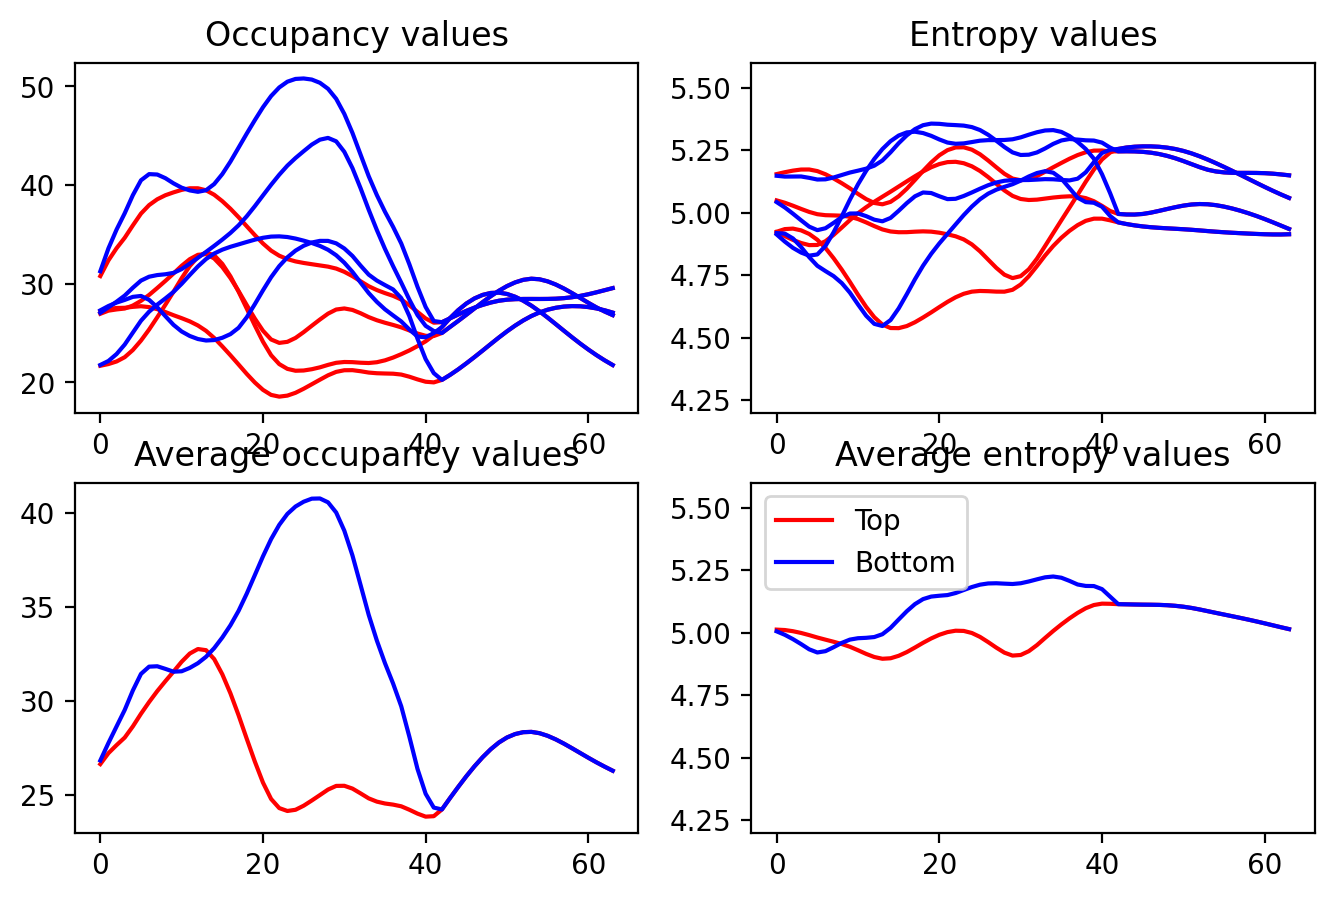

In [1424]:
from src.chromatin_entropy import plot_occupancy_entropy_set
plot_occupancy_entropy_set(config1, gene_occupancies, gene_entropies)

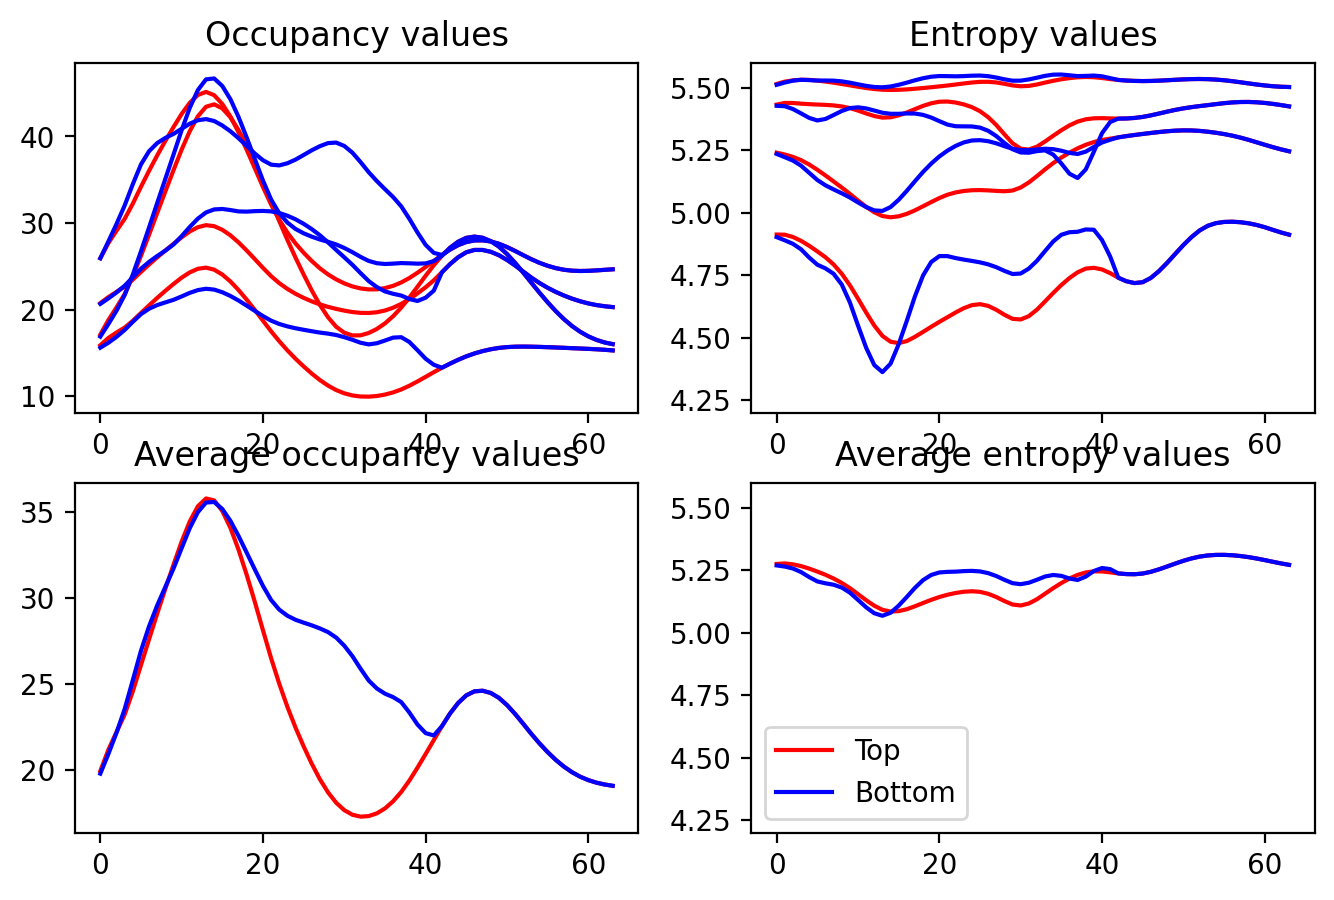

In [1420]:
plot_occupancy_entropy_set(config1, interg_occupancies, interg_entropies)

In [1425]:
from src.find_optimal_kappa_chromatin import compute_mean_tb_l2

mean_l2_gene_occ, mean_l2_gene_entropy = compute_mean_tb_l2(config1, 
    gene_occupancies, gene_entropies)

mean_l2_intergenic_occ, \
mean_l2_intergenic_entropy = compute_mean_tb_l2(config1, interg_occupancies, 
                                                interg_entropies)

print("Gene:")
print("\tOccupancy:", mean_l2_gene_occ)
print("\tEntropy", mean_l2_gene_entropy)

print("Intergenic:")
print("\tOccupancy:", mean_l2_intergenic_occ)
print("\tEntropy", mean_l2_intergenic_entropy)


Gene:
	Occupancy: 0.38630608829293955
	Entropy 0.0073922364205841785
Intergenic:
	Occupancy: 0.22586882703605624
	Entropy 0.003908894557068059


In [ ]:
from src.find_optimal_kappa_chromatin import DSE_GENES, INTERGENICS
from src.find_optimal_kappa_chromatin import deconvolve_and_plot_region, deconvolve_and_plot_gene
    
directory = f'output/chromatin_kappa_sweep/'
mkdir_safe(directory)

filename_format = "{}_kappa{}_gamma{}_F.npy"

gamma = 0.0076

k_min, k_max = 1e-4, 1e-1
logks = np.linspace(np.log10(k_min), np.log10(k_max), 4)
kappas = 10**logks
window = 500
    
groups = ['gene', 'intergenic']
meta_df = pd.DataFrame()

timer = Timer()

for k_i, kappa in enumerate(kappas):
    print("Kappa: ", kappa)

    for g_i, gene_name in enumerate(DSE_GENES):
        filename = filename_format.format(gene_name, kappa, gamma)
        save_path = f"{directory}/{filename}"
            
        row_df = pd.DataFrame({
            'path': save_path,
            'name': gene_name,
            'group': 'gene',
            'kappa': kappa,
            'gamma': gamma,
            'window': window
        }, index=[0])
        
        # Deconvolve and save to disk
        deconvolve_and_plot_gene(config1, gene_name, gamma=gamma, kappa=kappa, 
            output_directory=None, f_savepath=save_path, window=500, save_plots=False)

        timer.print_time("Saved:", save_path)
        meta_df = pd.concat([meta_df, row_df])

    for i_i, interg_name in enumerate(INTERGENICS):
        filename = filename_format.format(interg_name, kappa, gamma)
        interg_split_name = interg_name.split('_')
        chrom, mid = int(interg_split_name[0]), int(interg_split_name[1])
        save_path = f"{directory}/{filename}"

        row_df = pd.DataFrame({
            'path': save_path,
            'name': interg_name,
            'group': 'intergenic',
            'kappa': kappa,
            'gamma': gamma,
            'window': window
        }, index=[0])

        # Deconvolve and save to disk
        deconvolve_and_plot_region(config1, chrom, mid, gamma=gamma, kappa=kappa, 
            output_directory=None, f_savepath=save_path, window=500, save_plots=False)
        timer.print_time("Saved:", save_path)
        meta_df = pd.concat([meta_df, row_df])

meta_df = meta_df.set_index('name')
meta_df.to_csv(f'{directory}/meta.csv')


Creating directory: output/chromatin_kappa_sweep/...Directory exists. Skipping.
Kappa:  0.0001
Loading trial replication profile, 2/17/25
Loading chromosome reads: 5
